## Importing required libraries and modules

In [2]:
from IPython.display import display
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.cosmology import FlatLambdaCDM
from astroquery.vizier import Vizier
from scipy.spatial import KDTree
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

from sklearn.metrics.cluster import (
    adjusted_rand_score, normalized_mutual_info_score,
    fowlkes_mallows_score, pair_confusion_matrix,
)


## Phase 1: Data


### 1.1 Querying the data

We use the Tempel et al. (2014) SDSS DR10 group catalog and the query returns several tables:

**Galaxies:** The per-galaxy table (positions, redshifts, magnitudes, and Tempel's group IDs). This is the only table we use.

**Groups:** Tempel's per-group properties.

**vNNN_gal / vNNN_gr:**
Tempel's group-finding runs at different line-of-sight linking velocities.

We pull the full galaxies table with row_limit=-1 because we will apply our own volume-limited cuts. Tempel's GroupID and Ngal columns are kept only as ground truth labels for validation, they never enter the network construction.


In [3]:
# importing the labeled Galaxy Clusters via Vizier from Tempel's SDSS DR10 catalog
vizier = Vizier(columns=['GalID','RAJ2000','DEJ2000','zobs','rmag','GroupID','Ngal'], row_limit=-1)
print("Querying Vizier for galaxy cluster data...")
catalogs = vizier.get_catalogs("J/A+A/566/A1")
print("Found these tables: \n")
print(catalogs.keys())


Querying Vizier for galaxy cluster data...
Found these tables: 

['J/A+A/566/A1/galaxies', 'J/A+A/566/A1/groups', 'J/A+A/566/A1/v180_gr', 'J/A+A/566/A1/v180_gal', 'J/A+A/566/A1/v185_gr', 'J/A+A/566/A1/v185_gal', 'J/A+A/566/A1/v190_gr', 'J/A+A/566/A1/v190_gal', 'J/A+A/566/A1/v195_gr', 'J/A+A/566/A1/v195_gal', 'J/A+A/566/A1/v200_gr', 'J/A+A/566/A1/v200_gal', 'J/A+A/566/A1/v205_gr', 'J/A+A/566/A1/v205_gal', 'J/A+A/566/A1/v210_gr', 'J/A+A/566/A1/v210_gal']


### 1.2 Cosmology and the volume-limited sample

We adopt a flat ΛCDM cosmology with $ H_0 = 100\,\mathrm{km\,s^{-1}\,Mpc^{-1}}, \Omega_m = 0.27 $

so all distances throughout the project are expressed in $h^{-1} Mpc$ by construction.

The Main Galaxy Sample (mgs) is built in three steps:

**Column selection:** keep GalID, ra, dec, z, m, GroupID, Ngal from Tempel. GroupID and Ngal are reserved for validation only.

**Redshift slice:** $0.02 \le z \le 0.06$

Lower bound avoids local peculiar velocity contamination and upper bound keeps the comoving volume small enough that a single linking length remains meaningful. (higher redshift values add complexities to the problem that we avoid in this project)

**Volume-limited cut:** SDSS is a flux-limited survey. this means that faint galaxies in small redshifts who would be invisible in higher redshifts, must be filtered to keep the sample uniform.

we define the absolute magnitude limit at $⁡z_{\max}$​,

>    $$M_{\text{lim}} \;=\; m_{\text{lim}} \;-\; \mu(z_{\max}),$$
with  $m_{\text{lim}} = 17.77$ (SDSS Main Sample). Galaxies fainter than $M_{\text{lim}}$ at any redshift in the slice are discarded. This guarantees uniform completeness across the volume.

In [4]:
#defines the cosmology
cosmo = FlatLambdaCDM(H0=100, Om0=0.27)
# Grab the first table (the galaxy list)
df = catalogs[0].to_pandas()

# Keep only the columns we actually need for the math and the network
df = df[['GalID', 'RAJ2000', 'DEJ2000', 'zobs','rmag', 'GroupID', 'Ngal']].copy()

# Rename them to simple, standard variables
df.rename(columns={
    'RAJ2000': 'ra', 
    'DEJ2000': 'dec', 
    'zobs': 'z',
    'rmag': 'm'
}, inplace=True)
# forming our main galaxy sample dataframe (mgs)
# Filter the data to a specific "slice" of the universe (Redshift between 0.02 and 0.06)
z_max = 0.06
z_min = 0.02
mgs = df[
    (df['z'] >= z_min) & 
    (df['z'] <= z_max)
    ].copy()
# also filter to only exclude galaxies fainter than the derived absolute magnitude limit
m_limit = 17.77 # Apparent magnitude limit of SDSS Main Galaxy Sample  # Luminosity distance at z_max in parsecs
M_Limit = m_limit - cosmo.distmod(z_max).value  # Absolute magnitude limit at z_max
mgs['M'] = mgs['m'] - cosmo.distmod(mgs['z']).value # Absolute magnitude for each galaxy
mgs = mgs[mgs['M'] <= M_Limit].copy()
mgs.reset_index(drop=True, inplace=True)

print(f"Number of galaxies before cuts: {len(df)}")
print(f"Number of galaxies after cuts: {len(mgs)}")
print(f"Sample catalog:")
display(mgs.sample(5).style.set_caption("Filtered data"))

Number of galaxies before cuts: 588193
Number of galaxies after cuts: 75042
Sample catalog:


,GalID,ra,dec,z,m,GroupID,Ngal,M
8512,84790,212.875560,55.446790,0.041970,16.198999,1769,20,-19.370341
6622,22924,254.092430,26.633230,0.035780,15.214000,1379,31,-19.998712
27878,195934,160.899890,44.446950,0.058690,16.846001,9577,6,-19.478431
3595,223699,223.191600,16.947150,0.043630,16.950001,619,156,-18.706288
26189,18384,175.507450,65.198180,0.042080,15.057000,8371,4,-20.518219


### 1.3 Coordinate conversion

The tempel catalog gives each galaxy as (d, $\alpha , \delta$). To build our network, we need to convert them to cartesian coordinates (X,Y,Z).

$ X = d\cos(\delta)\cos(\alpha) $

$ Y = d\cos(\delta)\sin(\alpha) $

$ Z = d\sin(\delta) $

Where d is the comoving distance and ("ra" as $\alpha$ and "dec" as $\delta$) are the equatorial coordinates.

With Earth sitting at the origin; the line of sight to galaxy $i$ is the vector $\hat{r}_i = \frac{(X,Y,Z)}{|(X,Y,Z)|}$

This is what later allows us to decompose it into a transverse component $r_\perp$ and a line-of-sight component $r_\parallel$.

In [5]:
# Calculate comoving distance in h^-1 Mpc
mgs['distance_hinv_mpc'] = cosmo.comoving_distance(mgs['z']).to(u.Mpc).value / cosmo.h

# Summon the skycoord and let it do its magic. [this could be done using numpy but we are astrophysicists =) ]
coords = SkyCoord(
    ra=mgs['ra'].values * u.degree,
    dec=mgs['dec'].values * u.degree,
    distance=mgs['distance_hinv_mpc'].values * u.Mpc
    )

# Extract the 3D coordinates
mgs['X'] = coords.cartesian.x.value
mgs['Y'] = coords.cartesian.y.value
mgs['Z'] = coords.cartesian.z.value

print("Here are the 3D coordinates:")
display(mgs[['GalID', 'X', 'Y', 'Z', 'GroupID']].sample(5).style.set_caption("3D Coordinates with GroupID"))

Here are the 3D coordinates:


,GalID,X,Y,Z,GroupID
22613,13413,-66.622161,-122.757523,31.286003,6334
29931,191879,-122.751316,61.598655,12.077241,11165
39394,71822,-149.125953,80.436209,28.449742,25519
29437,24379,-81.501424,-93.622363,36.962091,10726
1984,71373,-100.695112,45.920568,49.061277,474


________________________________________________________________________________________________
## Phase 2: Method


### 2.1 Cylindrical linking criterion

Nodes are the galaxies. in phase 2 we set a criterion to define the conditions under which two nodes get connected.

**Spatial Search:** the KDTree on the redshift-space Cartesian coordinates lets us find all pairs within radius $r$ efficiently.
**Anisotropic linking.** A pure spherical FoF underperforms in redshift space because virialized galaxies have peculiar velocities of $\sim 300$–$500$ km/s, smearing groups along the line of sight by several Mpc. We therefore use a **cylindrical** linking criterion:

A pair $(i, j)$ is linked if

$$
d_\perp \leq r_\perp \quad \text{and} \quad d_\parallel \leq r_\parallel = S \cdot r_\perp .
$$

where S is the **Stretch factor:** Currently fixed at $S = 10$.

Here $\hat{\ell}_{ij}$ is the unit line-of-sight vector at the midpoint $(\vec{r}_i + \vec{r}_j) / 2$, so

$$
d_\parallel = \left| (\vec{r}_i - \vec{r}_j) \cdot \hat{\ell}_{ij} \right|,
\qquad
d_\perp = \sqrt{ |\vec{r}_i - \vec{r}_j|^2 - d_\parallel^2 }.
$$

The KDTree first returns all pairs inside the bounding sphere with $r_{\max} = \sqrt{r_\perp^2 + r_\parallel^2}$ and then filters precisely with the cylinder condition.

In [6]:
# Build KDTree for spatial searching
coordinates = mgs[['X', 'Y', 'Z']].values
tree = KDTree(coordinates)
number_of_galaxies = len(mgs)

# Define the stretching factor for the "Fingers of God"
# Typically, clusters stretch about 5 to 8 times longer along the line of sight
stretch_factor = 10

# Helper function to find edges using a cylinder
def get_cylindrical_edges(r_perp, stretch, coords, kd_tree):
    r_par = r_perp * stretch
    r_max = np.sqrt(r_perp**2 + r_par**2) # The bounding sphere

    # Spherical search to get candidate pairs
    pairs = kd_tree.query_pairs(r_max, output_type='ndarray') 
    if len(pairs) == 0:
        return np.empty((0, 2), dtype=int)
    idx_i, idx_j = pairs[:, 0], pairs[:, 1]
    pos_i = coords[idx_i]
    pos_j = coords[idx_j]
    
    # Vector math
    diff = pos_i - pos_j
    los = (pos_i + pos_j) # Line of sight vector from Earth (0,0,0)
    los_norm = np.linalg.norm(los, axis=1)
    
    # Calculate parallel (d_par) and perpendicular (d_perp) distances
    dot_product = np.sum(diff * los, axis=1)
    d_par = np.abs(dot_product) / los_norm
    
    diff_sq = np.sum(diff**2, axis=1)
    # np.clip prevents math errors from floating point precision
    d_perp = np.sqrt(np.clip(diff_sq - d_par**2, 0, None)) 
    
    # Filter the edges to only those inside the cylinder
    valid_mask = (d_perp <= r_perp) & (d_par <= r_par)
    return np.column_stack([idx_i[valid_mask], idx_j[valid_mask]])


### 2.2 Percolation scan

We sweep the perpendicular linking length $r_\perp$ and, at each value, compute two independent observables of the resulting cylindrical graph.

**Susceptibility**:

$$
\chi(r_\perp) \;=\; \frac{1}{N} \sum_{s \neq \text{GCC}} s^2 \, n_s ,
$$

where the sum runs over all finite components (excluding the giant connected component), $s$ is component size, $n_s$ is the number of components of that size, and $N$ is the total number of galaxies. $\chi$ diverges at the percolation threshold $r_c$ — the linking length at which an infinite cluster first spans the system. We identify $r_{\rm critical}$ as the location of the first peak of $\chi$.

**Number of valid groups** :

Since we are trying to find the galaxy groups which are the smallest populations of galaxies, (we are not looking for galaxy clusters and superclusters) we can look for the maximum fragmentation to find our groups.
for each $r_\perp$ we will have a set of connected components (c) with different populations. we call this set $G_r$. therefore:

$$
N_{\rm groups}(r_\perp) \;=\; |\{\, c \in G_r  |  2 \leq |c| < |\text{GCC}| \,\} |.
$$

This counts the connected components that are neither isolated galaxies nor part of the GCC. Its peak identifies the linking length at which the network is most fragmented into distinct groups *before* those groups begin to merge into a percolating filamentary network. We take this $r_{\rm groups}$ as the working linking length for group identification.

**Why both?**
$r_{\rm critical}$ is the percolation phase transition, it is the linking length which can form clusters and super clusters.
while this demonstrates the hierarchial structure of the network, we also use the $r_{\rm critical}$ as an upper bond to stay in the sub-critical regime. $r_{\rm groups} < r_{\rm critical}$.

  Since $r_{\rm groups}$ is the actual group-finding scale, we call it $r_{\rm link}$. 

In [7]:
# 3. Compute susceptibility (chi) by sweeping the perpendicular radius
r_perp_values = np.arange(0.1,3 ,.02)
susceptibilities =[]
gcc_percentages = []
num_valid_groups =[]
for r_perp in r_perp_values:
    edges = get_cylindrical_edges(r_perp, stretch_factor, coordinates, tree)
    #make a temporary graph to find connected components for each radius
    temp_graph = nx.Graph()
    temp_graph.add_nodes_from(range(number_of_galaxies))
    temp_graph.add_edges_from(edges)
    components = list(nx.connected_components(temp_graph))
    # only consider groups with at least 2 members and exclude the giant component
    valid_groups =[c for c in components if len(c) >= 2 and len(c) < max(len(cp) for cp in components)]
    num_valid_groups.append(len(valid_groups))
    if len(components) <= 1:
        susceptibilities.append(0)
        continue
    
    gcc_size = max(len(c) for c in components)
    finite_components = [c for c in components if len(c) < gcc_size]
    gcc_percentages.append(100 * gcc_size / number_of_galaxies)

    if not finite_components:
        susceptibilities.append(0)
        continue
        
    chi = sum(len(c)**2 for c in finite_components) / number_of_galaxies
    susceptibilities.append(chi)

r_critical_perp = r_perp_values[np.argmax(susceptibilities)]
r_groups_perp = r_perp_values[np.argmax(num_valid_groups)] 

print(f"Topological Percolation Threshold (Perp): {r_critical_perp:.2f} h^-1 Mpc")
print(f"Topological Group Threshold (Perp): {r_groups_perp:.2f} h^-1 Mpc")
print(f"Implied Line-of-Sight Threshold (Par): {r_groups_perp * stretch_factor:.2f} h^-1 Mpc")


Topological Percolation Threshold (Perp): 1.34 h^-1 Mpc
Topological Group Threshold (Perp): 0.54 h^-1 Mpc
Implied Line-of-Sight Threshold (Par): 5.40 h^-1 Mpc


### 2.3 Linking parameter b

In the classical Friends-of-Friends literature, the linking length is reported as a dimensionless ratio:

$$
b \equiv \frac{r_{\rm link}}{\bar{d}}, \qquad \bar{d} = n^{-1/3}, \qquad
n = \frac{N_{\rm gal}}{V_{\rm shell}},
$$

where $\bar{d}$ is the average inter-galaxy spacing and $n$ is the number density of the volume-limited sample.

There are 2 reference methods to apply here,Earlier Papers like **Davis et al. 1985** use a fixed $b \in [0.14,\, 0.20]$, while
**Tempel et al. (2014)** Uses a redshift-dependent linking length. ($b \approx 0.113$-$0.115$ for the volume-limited samples that overlap our redshift slice ($0.02 \leq z \leq 0.06$).

We compute $b$ here only as a validation of our topologically-derived $r_{\rm groups}$. It will not be used as an input to the algorithm for calibration.

**Volume of the sample.** The volume-limited slice occupies a spherical shell between the comoving distances at $z_{\min}$ and $z_{\max}$, restricted to the SDSS footprint:

$$
V_{\rm shell} \;=\; \frac{4\pi}{3}\,(d_{\max}^{3} - d_{\min}^{3}) \,\cdot\, f_{\rm sky},
\qquad f_{\rm sky} = \frac{7221\,{\rm deg}^2}{41252.96\,{\rm deg}^2}.
$$

Where $d_{\min}$ and $d_{\max}$ are the comoving distances at $z_{\min}$ and $z_{\max}$ and the sky fraction $f_{\rm sky}$ corresponds to the SDSS Main Galaxy Sample footprint of $\sim 7221\,{\rm deg}^2$ devided by the area of a full sphere.

In [8]:
SDSS_sky_fraction = 7221 / 41252.96
d_min = cosmo.comoving_distance(z_min).value 
d_max = cosmo.comoving_distance(z_max).value 
limited_volume = (4/3) * np.pi * (d_max**3 - d_min**3) * SDSS_sky_fraction
number_density = number_of_galaxies / limited_volume
d_mean = number_density**(-1/3)
b = r_groups_perp / d_mean
print(f"\nLinking parameter b = {b:.3f}")
print(f"Tempel comparison : b ≈ 0.113–0.115")
print(f"Classical FoF range (Davis 1985, Berlind 2006): 0.14 < b < 0.20")


Linking parameter b = 0.144
Tempel comparison : b ≈ 0.113–0.115
Classical FoF range (Davis 1985, Berlind 2006): 0.14 < b < 0.20


### 2.4 GCC diagnostic
The GCC represents the single largest connected structure in the network. As the linking length $r_\perp$ increases, the network undergoes a percolation transition where small, isolated galaxy groups rapidly merge into a massive super structure spanning the entire sampled volume. 

One could aproach this problem by evaluating this transition by assessing the derivative of the GCC fraction with respect to $r_\perp$ ($\frac{d(\text{GCC})}{d r_\perp}$). The point at which the GCC grows most rapidly (the maximum gradient) is a classical heuristic for estimating the percolation threshold. Another method would be to find the maximum susceptibilty of the graph and set the corresponding $r_c$ as the linking length.

The challenge we are facing here though requires more attention. We have a graph of galaxies that has multiple structures inside it: groups of galaxies (which we are hunting!), clusters and superclusters. each with their unique properties and characteristics.

It reveals that using the susceptibility and maximum gradient methods leads to finding the linking length which forms cluster and superclusters while we are looking for smaller groups.
We therefore use the maximum fragmentation method; since we are looking for the smallest structure of the network, we start to look for the radius at which the smallest groups start to form. since they are the smallest groups, it is somehow trivial that at this point, we will see the maximum number of groups formed inside the network. and then assign the corresponding $r_\perp$ as the linking length to form our network.
By plotting the GCC coverage, we can visually diagnose the phase transition and compare this inflection point against our explicitly defined topological markers:
- **Maximum fragmentation** ($r_{\rm groups}$): The linking length where we capture isolated groups before they merge.
- **Susceptibility peak** ($r_{\rm critical}$): The true topological percolation threshold.
- **Max gradient location**: The steepest growth phase of the supercluster network.

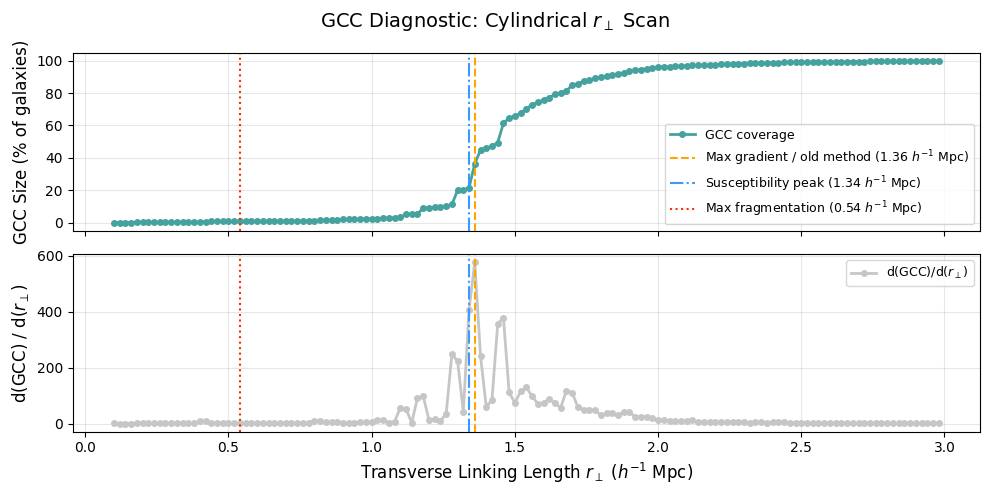

Max gradient r_c (old method):      1.36 h^-1 Mpc
Susceptibility peak (r_critical):    1.34 h^-1 Mpc
Max fragmentation (r_groups):        0.54 h^-1 Mpc


In [9]:
gcc_array = np.array(gcc_percentages)

#differentiate to find the inflection point (max gradient)
dgcc = np.gradient(gcc_array, r_perp_values)
r_max_gradient = r_perp_values[np.argmax(dgcc)]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
fig.suptitle(r'GCC Diagnostic: Cylindrical $r_\perp$ Scan', fontsize=14)

# --- Top panel: GCC coverage ---
ax1.plot(r_perp_values, gcc_array, marker='o', markersize=4,
         color='#45A29E', linewidth=2, label='GCC coverage')
ax1.axvline(x=r_max_gradient, color='orange', linestyle='--',
            label=f'Max gradient ({r_max_gradient:.2f} $h^{{-1}}$ Mpc)')
ax1.axvline(x=r_critical_perp, color="#379BFF", linestyle='-.',
            label=f'Susceptibility peak ({r_critical_perp:.2f} $h^{{-1}}$ Mpc)')
ax1.axvline(x=r_groups_perp, color='#FB2E00', linestyle=':',
            label=f'Max fragmentation ({r_groups_perp:.2f} $h^{{-1}}$ Mpc)')
ax1.set_ylabel('GCC Size (% of galaxies)', fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# --- Bottom panel: gradient of GCC ---
ax2.plot(r_perp_values, dgcc, marker='o', markersize=4,
         color='#C5C6C7', linewidth=2, label=r'd(GCC)/d($r_{\perp}$)')
ax2.axvline(x=r_max_gradient, color='orange', linestyle='--')
ax2.axvline(x=r_critical_perp, color="#379BFF", linestyle='-.')
ax2.axvline(x=r_groups_perp, color='#FB2E00', linestyle=':')
ax2.set_xlabel(r'Transverse Linking Length $r_{\perp}$ ($h^{-1}$ Mpc)', fontsize=12)
ax2.set_ylabel(r'd(GCC) / d($r_{\perp}$)', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Max gradient r_c:      {r_max_gradient:.2f} h^-1 Mpc")
print(f"Susceptibility peak (r_critical):    {r_critical_perp:.2f} h^-1 Mpc")
print(f"Max fragmentation (r_groups):        {r_groups_perp:.2f} h^-1 Mpc")

### 2.5 Building the final graph

With $r_{\rm groups}^\perp$ found by the maximum fragmentation, we build the final graph using the same cylindrical FoF method we used before, run once at the chosen linking length.

In [10]:
#Build the Final Network
final_edges = get_cylindrical_edges(r_groups_perp, stretch_factor, coordinates, tree)
G = nx.Graph()
G.add_nodes_from(range(number_of_galaxies))
G.add_edges_from(final_edges)

print(f"NETWORK BUILT! Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")

NETWORK BUILT! Nodes: 75042 | Edges: 95310


### 2.6 Forming galaxy groups

In the cylindrical FoF method, **connected components of the linking graph are the galaxy groups**. Two galaxies belong to the same group if a chain of pairwise linkings exists between them (the friends-of-friends rule).

We assign a unique integer to each connected component which will be added as a column in mgs dataframe. so after this part, each galaxy has:

- `GroupID`: Tempel's reference label. NaN for field galaxies (single galaxies which do not belong to any group).
- `Detected_GroupID`: our graph-derived label (this is always assigned. even field galaxies get their own distinct ID).

In [11]:
# Connected components ARE the groups
groups = list(nx.connected_components(G))
group_labels = np.zeros(len(mgs), dtype=int)
for group_id, members in enumerate(groups):
    for node in members:
        group_labels[node] = group_id

mgs['Detected_GroupID'] = group_labels

## Phase 3: Results

### 3.1 Phase-transition figure

This is the figure the entire method rests on. It plots, on a shared $r_\perp$ axis, the two independent topological observables computed during the percolation scan:

- **Susceptibility $\chi(r_\perp)$** peaks at the percolation threshold $r_{\rm critical}^\perp$. Its peak marks the linking length at which an infinite cluster first spans the system.
- **Fragmentation count $N_{\rm groups}(r_\perp)$** counts finite components of size $2 \leq s < |\text{GCC}|$. Its peak marks the linking length at which the network is most fragmented into distinct, finite groups, before merging into the percolating phase.

Two vertical lines mark $r_{\rm critical}^\perp$ and $r_{\rm groups}^\perp$. The defining property of the method that makes the chosen $r_{\rm groups}^\perp$ a *group* scale rather than a *cluster* scale — is the inequality

$$
r_{\rm groups}^\perp < r_{\rm critical}^\perp.
$$

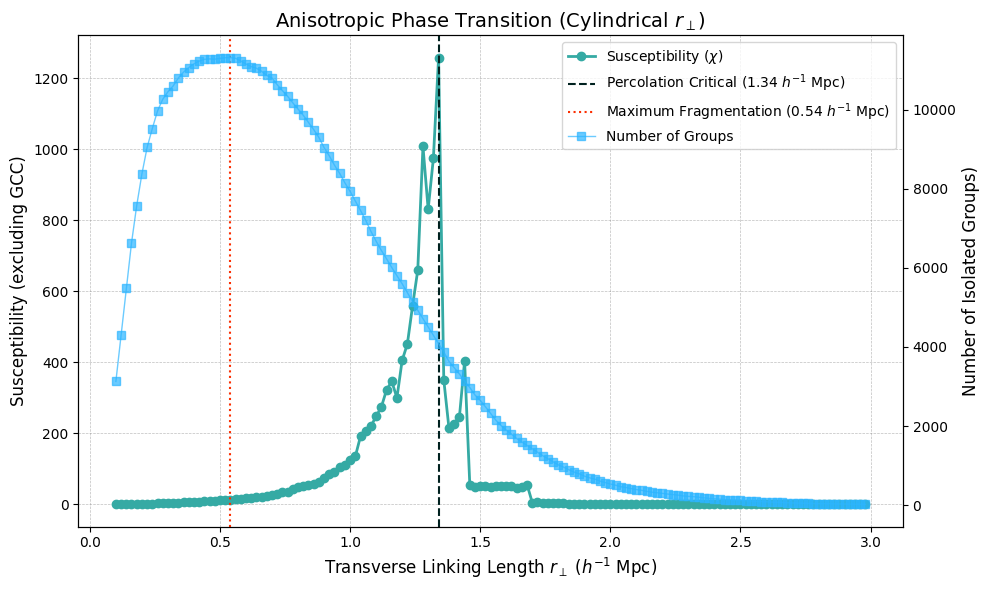

In [15]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Susceptibility
ax1.plot(r_perp_values, susceptibilities, marker='o', linestyle='-', color="#35AAA4", linewidth=2, label=r'Susceptibility ($\chi$)')

# Mark the critical points
ax1.axvline(x=r_critical_perp, color="#00211F", linestyle='--', label=f'Percolation Critical ({r_critical_perp:.2f} $h^{{-1}}$ Mpc)')
ax1.axvline(x=r_groups_perp, color="#FB2E00", linestyle=':', label=f'Maximum Fragmentation ({r_groups_perp:.2f} $h^{{-1}}$ Mpc)')

ax1.set_title(r"Anisotropic Phase Transition (Cylindrical $r_{\perp}$)", fontsize=14, color='black')
ax1.set_xlabel(r"Transverse Linking Length $r_{\perp}$ ($h^{{-1}}$ Mpc)", fontsize=12, color='black')
ax1.set_ylabel("Susceptibility (excluding GCC)", fontsize=12, color='black')
ax1.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Add a twin axis to show the number of groups (Maximum fragmentation)
ax2 = ax1.twinx()
ax2.plot(r_perp_values, num_valid_groups, marker='s', linestyle='-', color="#2CB5FF", linewidth=1, alpha=0.7, label='Number of Groups')
ax2.set_ylabel("Number of Isolated Groups)", fontsize=12, color='black')

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.tight_layout()
plt.show()

### 3.2 Group catalogue

Aside from statistical validations, To check whether the group catalogue behaves uniformly across the volume and whether the  $r_{\rm groups}^\perp$ remains a reasonable linking length at all redshifts in the slice, we project the RA($\alpha$), DEC($\delta$) plane in four redshift bins of width $\Delta z = 0.01$, and plot the detected groups alongside Tempel's reference.

Each column corresponds to one redshift bin. grouped galaxies are coloured by `Detected_GroupID` (left) or Tempel `GroupID` (right) with marker size scaled by group richness while field galaxies are shown in grey.

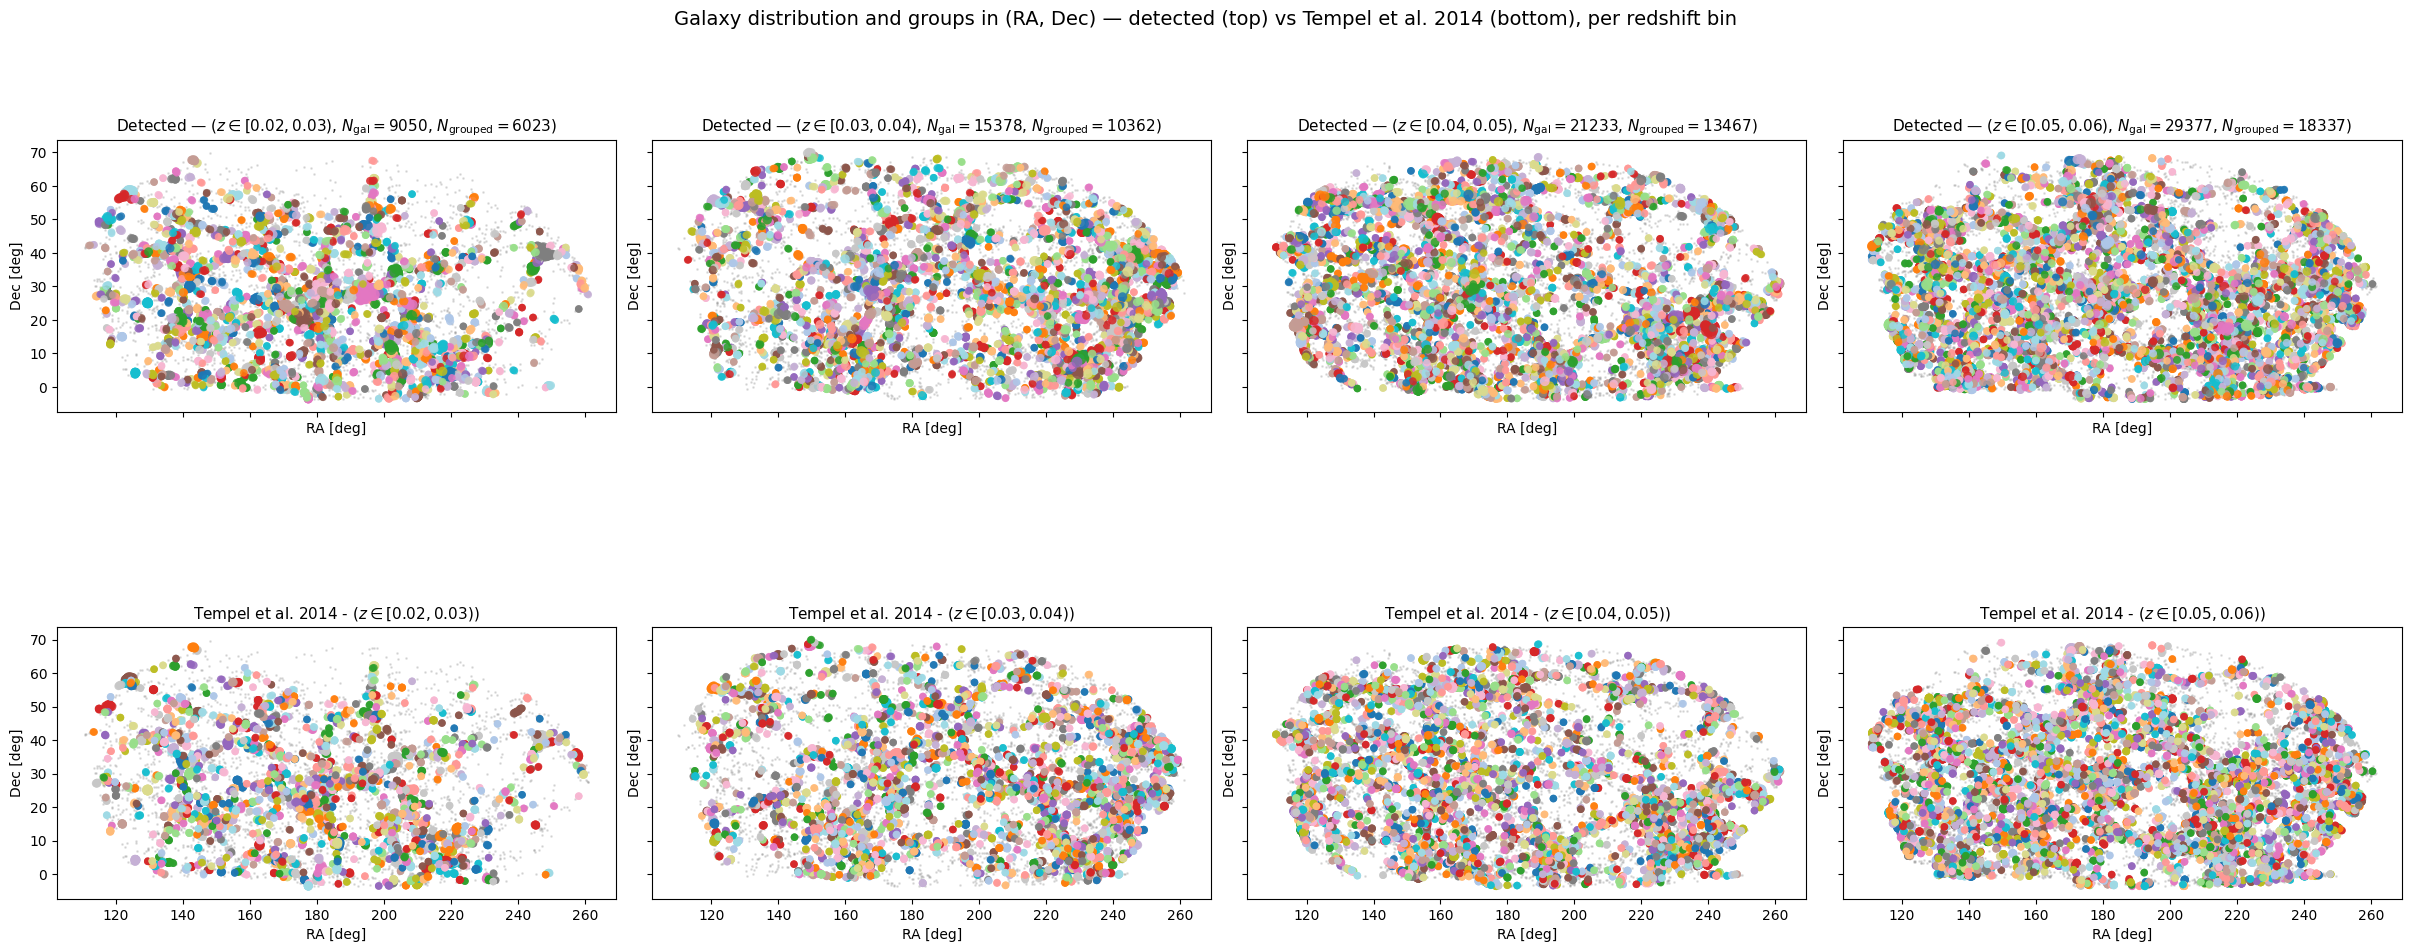

In [13]:
def make_group_colors(group_ids, seed=0):
    """Stable shuffled qualitative colour map (suggestion 3)."""
    rng = np.random.default_rng(seed)
    base = plt.cm.tab20(np.linspace(0, 1, 20))
    unique = np.asarray(sorted(group_ids))
    perm = rng.permutation(len(unique))
    return {gid: base[perm[i] % 20] for i, gid in enumerate(unique)}


def plot_radec_panel(ax, mgs, group_col, z_lo, z_hi, *, panel_title):
    """One RA-Dec panel, sliced in redshift."""
    slab = mgs[mgs['z'].between(z_lo, z_hi, inclusive='left')]

    counts = slab[group_col].value_counts(dropna=True)
    grouped_ids = counts[counts > 1].index
    is_grouped = slab[group_col].isin(grouped_ids) & slab[group_col].notna()

    grouped = slab[is_grouped]
    isolated = slab[~is_grouped]

    # background of singletons / field galaxies
    ax.scatter(isolated['ra'], isolated['dec'],
               c='grey', s=1, alpha=0.2, label='Isolated / field')

    # grouped galaxies — coloured + sized by richness
    if len(grouped) > 0:
        richness = grouped[group_col].map(counts).astype(float)
        sizes = (5.0 + 1.5 * np.log10(richness)) ** 2
        cmap = make_group_colors(grouped_ids)
        colors = np.array([cmap[g] for g in grouped[group_col].values])
        ax.scatter(grouped['ra'], grouped['dec'],
                   c=colors, s=sizes, alpha=0.85, edgecolors='none',
                   label='Grouped')

    ax.set_xlabel('RA [deg]')
    ax.set_ylabel('Dec [deg]')
    ax.set_aspect('equal')
    ax.set_title(panel_title, fontsize=11)
    return len(slab), len(grouped)


# --- main figure ---------------------------------------------------------

z_edges = np.arange(z_min, z_max + 1e-9, 0.01)   # [0.02, 0.03, 0.04, 0.05, 0.06]
n_bins = len(z_edges) - 1                          # 4 bins

# Adjusted figsize to better match a 2-row x 4-column layout with equal aspect ratio plots.
# A very tall height is what was causing the extra blank spaces.
fig, axes = plt.subplots(2, n_bins,
                         figsize=(24, 10),
                         constrained_layout=True,
                         sharex=True, sharey=True)

# Make sure axes is always 2D, even if n_bins == 1.
if axes.ndim == 1:
    axes = axes[np.newaxis, :]

for col, (z_lo, z_hi) in enumerate(zip(z_edges[:-1], z_edges[1:])):

    n_slab, n_det = plot_radec_panel(
        axes[0, col], mgs,
        group_col='Detected_GroupID',
        z_lo=z_lo, z_hi=z_hi,
        panel_title=(f'Detected-  '
                     f'($z \\in [{z_lo:.2f}, {z_hi:.2f})$, '
                     f'$N_{{\\rm gal}} = {n_slab if False else 0}$)'),
    )
    plot_radec_panel(
        axes[1, col], mgs,
        group_col='GroupID',
        z_lo=z_lo, z_hi=z_hi,
        panel_title=(f'Tempel et al. 2014 - '
                     f'($z \\in [{z_lo:.2f}, {z_hi:.2f})$)'),
    )

    # Re-set the top-panel title now that we know n_slab and n_det.
    axes[0, col].set_title(
        f'Detected — ($z \\in [{z_lo:.2f}, {z_hi:.2f})$, '
        f'$N_{{\\rm gal}} = {n_slab}$, $N_{{\\rm grouped}} = {n_det}$)',
        fontsize=11,
    )

fig.suptitle(
    'Galaxy distribution and groups in (RA, Dec) — '
    'detected (top) vs Tempel et al. 2014 (bottom), per redshift bin',
    fontsize=14
)
plt.show()

### 3.3 Group-richness distribution

A simple side-by-side comparison of group sizes between our detected catalogue and Tempel et al. (2014). For each catalogue we count, per group, how many galaxies it contains, then plot a log-log histogram of those counts.

Both histograms are restricted to groups of richness $N \geq 2$, so single-galaxy components (field galaxies) are excluded from the comparison.
It is noteworthy that:
- **shift to higher N.** Indicates over-merging; meaning that small groups have linked larger clusters because the cylinder is too large.

- **shift to lower N.** Indicates under-merging and extreme fragmentation; meaning that rich clusters are being split because the cylinder is too tight (or the stretch factor is too short to absorb their full Fingers-of-God effect).

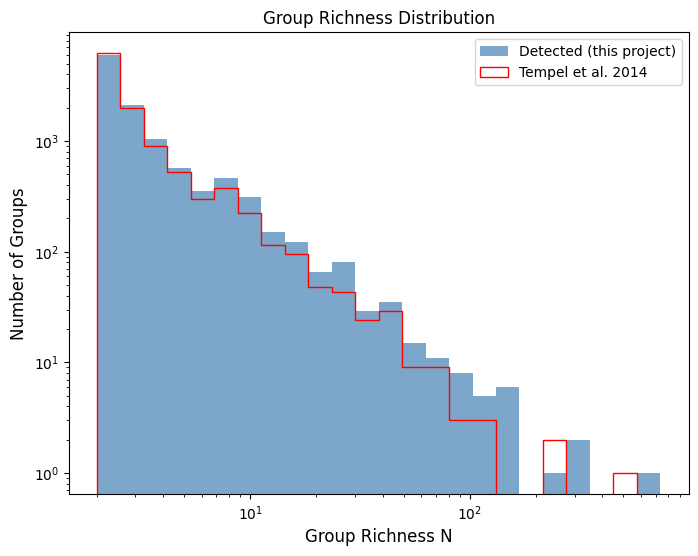

In [14]:
detected_sizes = mgs['Detected_GroupID'].value_counts()
detected_sizes = detected_sizes[detected_sizes >= 2] # Only considers groups of size 2 or more for the histogram

tempel_sizes = mgs['GroupID'].value_counts()
tempel_sizes = tempel_sizes[tempel_sizes >= 2] # Only considers groups of size 2 or more for the histogram

fig, ax = plt.subplots(figsize=(8, 6))
N_max = max(detected_sizes.max(), tempel_sizes.max())
bins = np.logspace(np.log10(2), np.log10(N_max)+0.1, 25)
ax.hist(detected_sizes, bins=bins, alpha=.7, histtype='stepfilled', label='Detected (this project)', color='steelblue')
ax.hist(tempel_sizes, bins=bins, histtype='step', label='Tempel et al. 2014', color='red')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Group Richness N', fontsize=12)
ax.set_ylabel('Number of Groups', fontsize=12)
ax.set_title('Group Richness Distribution', fontsize=12)
ax.legend()
plt.show()

## Phase 4: Validation & Assessment

### 4.1 Completeness and purity by richness bin

For each group in Tempel's catalog ($N \geq 2$),
we find the detected component with the largest membership overlap and
compute two metrics:

$$
\text{Completeness} = \frac{|T \cap D|}{|T|}, \qquad
\text{Purity} = \frac{|T \cap D|}{|D|},
$$

where $T$ is the set of Tempel members and $D$ is the set of members
in the best-matching detected group. Completeness measures how much
of a group we recovered and purity measures how contaminated our
detected group is by galaxies that do not belong to this group.

We report the mean of both metrics in richness bins. The expected
behaviour is high completeness across all bins (the cylinder captures
most members) with purity declining at high N (rich clusters have
large velocity dispersions that our fixed stretch factor fails to cover.)

In [12]:
# For each detected group, find its best-matching true group
# Completeness: what fraction of a true group did you recover?
# Purity: what fraction of your detected group is truly co-grouped?

results = []
for true_id in mgs['GroupID'].dropna().unique():
    true_members = set(mgs[mgs['GroupID'] == true_id].index)
    if len(true_members) < 2:
        continue
    
    # Find which detected group has most overlap
    detected_ids = mgs.loc[list(true_members), 'Detected_GroupID']
    best_detected = detected_ids.value_counts().index[0]
    detected_members = set(mgs[mgs['Detected_GroupID'] == best_detected].index)
    
    overlap = len(true_members & detected_members)
    completeness = overlap / len(true_members)
    purity = overlap / len(detected_members)
    
    results.append({
        'True_GroupID': true_id,
        'N_true': len(true_members),
        'Completeness': completeness,
        'Purity': purity
    })

validation_df = pd.DataFrame(results)
print(validation_df.groupby(pd.cut(validation_df['N_true'], 
      bins=[1,2,5,10,50,500]))[['Completeness','Purity']].mean())

           Completeness    Purity
N_true                           
(1, 2]         0.994617  0.824064
(2, 5]         0.992337  0.804612
(5, 10]        0.984191  0.778304
(10, 50]       0.983937  0.757173
(50, 500]      0.988517  0.752681


### 4.2 Global partition metrics: ARI, NMI, and Fowlkes-Mallows

We restrict to galaxies that Tempel placed in groups with at least two members,
making `y_true` and `y_pred` directly comparable label arrays.
The Adjusted Rand Index corrects for chance agreement;
the Normalised Mutual Information measures shared information between the two partitions;
the Fowlkes-Mallows index is the geometric mean of pair precision and recall.
All three are bounded in [0, 1] with 1 indicating a perfect match.

In [ ]:
grouped_mask = mgs['GroupID'].notna() & (mgs['Ngal'] >= 2)
sub = mgs[grouped_mask].copy()

y_true = sub['GroupID'].astype(int).values
y_pred = sub['Detected_GroupID'].values

ari = adjusted_rand_score(y_true, y_pred)
nmi = normalized_mutual_info_score(y_true, y_pred, average_method='arithmetic')
fm  = fowlkes_mallows_score(y_true, y_pred)

print(f"Galaxies in grouped subsample : {len(sub):,}")
print(f"Unique Tempel groups           : {sub['GroupID'].nunique():,}")
print(f"Unique detected groups         : {sub['Detected_GroupID'].nunique():,}")
print()
print(f"Adjusted Rand Index   (ARI)  = {ari:.4f}   [random = 0, perfect = 1]")
print(f"Norm. Mutual Info     (NMI)  = {nmi:.4f}   [random = 0, perfect = 1]")
print(f"Fowlkes-Mallows       (FM)   = {fm:.4f}   [random ≈ 0, perfect = 1]")


### 4.3 Pair-level precision, recall, and F1

The pair confusion matrix decomposes all galaxy pairs into four categories:
true positives (same group in both partitions),
false positives (linked by us, separated by Tempel),
false negatives (separated by us, linked by Tempel),
and true negatives (separated in both).
Pair precision and recall are the direct pair-level analogues of purity and completeness.

In [ ]:
pcm = pair_confusion_matrix(y_true, y_pred)
TN, FP, FN, TP = pcm.ravel()

pair_precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
pair_recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
pair_f1        = (2 * pair_precision * pair_recall / (pair_precision + pair_recall)
                  if (pair_precision + pair_recall) > 0 else 0.0)

print(f"Pair confusion matrix")
print(f"  TP = {TP:,}   FP = {FP:,}")
print(f"  FN = {FN:,}   TN = {TN:,}")
print()
print(f"Pair precision  (≈ purity)       = {pair_precision:.4f}")
print(f"Pair recall     (≈ completeness) = {pair_recall:.4f}")
print(f"Pair F1                          = {pair_f1:.4f}")


### 4.4 Network topology

We compare the final graph $G$ against an Erdős–Rényi null model with the same
node and edge counts. The key quantities are transitivity (the fraction of connected
triples that close into triangles) and the average local clustering coefficient.
A real galaxy network is far more clustered than a random graph: galaxies clump into
groups and filaments rather than linking uniformly. The ratio of observed clustering
to the ER expectation quantifies how far from random the detected structure is.

In [ ]:
degrees        = np.array([d for _, d in G.degree()])
n_nodes        = G.number_of_nodes()
n_edges        = G.number_of_edges()
p_er           = 2 * n_edges / (n_nodes * (n_nodes - 1))

transitivity   = nx.transitivity(G)
avg_clustering = nx.average_clustering(G)

print(f"Graph summary")
print(f"  Nodes      : {n_nodes:,}")
print(f"  Edges      : {n_edges:,}")
print(f"  Mean degree: {degrees.mean():.2f}  (max: {degrees.max()})")
print()
print(f"Clustering")
print(f"  Transitivity         : {transitivity:.4f}   (ER baseline: {p_er:.4f})")
print(f"  Avg local clustering : {avg_clustering:.4f}   (ER baseline: {p_er:.4f})")
print(f"  Ratio (obs / ER)     : {avg_clustering / p_er:.1f}x")
print()
n_components = nx.number_connected_components(G)
gcc_size     = max(len(c) for c in nx.connected_components(G))
print(f"Components")
print(f"  Total connected components : {n_components:,}")
print(f"  GCC size                   : {gcc_size:,}  ({100*gcc_size/n_nodes:.1f}% of nodes)")
